Sequential Search mencari data dengan cara membandingkan data yang dicari dengan setiap
data yang terdapat pada list satu persatu dari indeks awal sampai dengan indeks terakhir.
Sedangkan pada binary search, list data dibagi menjadi dua buah grup, dan pencarian akan
dilakukan dengan cara membandingkan data yang dicari dengan data yang terdapat pada indeks
tengah, jika data yang dicari lebih besar terhadap data yang terdapat pada indeks tengah, maka
pencarian berikutnya hanya dilakukan pada grup terakhir saja. Hal ini dilakukan terus menerus
(pembagian list menjadi dua buah grup, pembandingan data yang dicari dengan nilai tengah),
sampai data diketemukan, atau data tidak diketemukan. Oleh karena itu waktu komputasi yang
dibutuhkan untuk binary search lebih sedikit dibandingkan dengan sequential search, karena
pencarian tidak dilakukan pada setiap data, tapi hanya grup yang memenuhi syarat saja.
Algoritma searching yang ketiga adalah Hashing. Penjelasan algoritma hashing ini akan dibagi
menjadi tiga bagian, yaitu :
1. Hashing
2. Fungsi Hash
3. Penanganan Collusion

### 1. Hashing
Pencarian akan lebih cepat lagi jika semua data pada list terletak tepat berada ditempatnya
masing-masing, sehingga pencarian dilakukan hanya dengan satu kali proses perbandingan saja.
Algoritma ini dikenal dengan nama Hashing. Di dalam algoritma hashing ini terdapat beberapa
istilah dasar sebagai berikut:

- Hash Table, yaitu sebuah tempat penyimpanan data, yang dibuat sedemikian rupa, sehingga
dapat memudahkan pencarian. Tipe data list di python dapat digunakan untuk
merepresentasikan hash table
- slot, yaitu posisi (indeks) yang terdapat pada hash table sebagai tempat penyimpanan setiap
data. Karena slot berfungsi seperti halnya indeks, maka nilai slot adalah nilai integer mulai
dari nol sampai dengan ukurang dari hash table, misalkan slot 0, slot 1, slot 2, .... , slot .
Contoh hash table dan slot yang masih kosong dapat dilihat pada Gambar 1. Pada Gambar
tersebut terdapat sebuah hash table dengan 11 slot kosong :

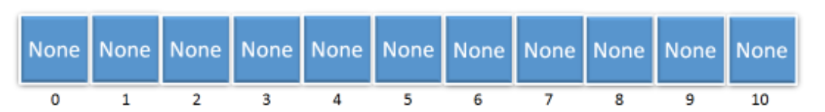

- Hash function, yaitu suatu fungsi yang memetakan antara data dengan slot di dalam hash
table

### 2. Fungsi Hash
Hash function ini memegang peranan penting dalam algoritma hashing, dengan hash function ini,
data didalam list disusun berdasarkan nilai hash, dan pencarian data dilakukan berdasarkan nilai
hash dari hash function ini. Hash function memiliki parameter nilai data (baik data yang akan
disusun didalam list ataukah data yang akan dicari), dan mengembalikan nilai integer (nilai hash)
yang merupakan representasi dari nomor slot.

Contoh hash function yang paling sederhana adalah remainder function. Pada fungsi ini,
parameter adalah nilai data, dan nilai balik berupa modulus dari data tersebut dengan sebuah
angka (misal ukuran dari tabel). Fungsi ini hanya menghitung modulus dari suatu data, contoh,
terdapat data dengan nilai 54, maka nilai hash = 54 % 11, yaitu 4.

Berikut contoh data dan nilai hash, dengan fungsi modulus 11 (ukuran tabel).

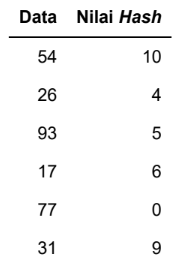

Sehingga dengan data dan nilai hash tersebut, maka representasi data di dalam hash table, dapat
dilihat pada Gambar berikut.

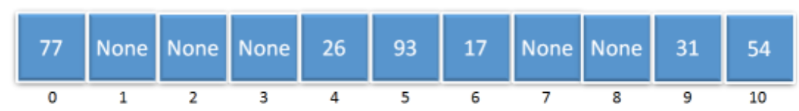

Setelah semua data berada di dalam hash table, maka dapat dihitung Load factor dari hash table,
yang merupakan presentasi pemakaian hash tabel, dengan menggunakan persamaan

λ =jumlahData/ukuranTabel

Pencarian data dilakukan hanya dengan cara menghitung function hash berdasarkan data
tersebut, dan nilai balik data tersebut merupakan index atau slot dari data di dalam list, kemudian
dilakukan pengecekan keberadaan data tersebut hanya dengan satu kali perbandingan saja.

#### Code
Berikut adalah fungsi-fungsi yang diperlukan untuk algoritma hashing ini, antara lain :
- hash function (gunakan remainder function, yaitu data dimodulus dengan 11), nilai balik
merupakan nilai hash
- createHashTable, untuk membuat hash table, dengan inisialisasi semua slot berisi 'none'
- putData, yaitu menyusun data ke dalam hash table, berdasarkan nilai hash yang dihasilkan
- searchHash, argumen merupakan data yang dicari, dan nilai balik berupa True or False, yaitu
apakah data ditemukan di dalam hash table

In [2]:
def remainderFunction (data,num):
    return (data%num)

def createHashTable(num):
    temp=[]
    for i in range(num):
        temp.append('none')
    return(temp)

def putData(data,table):
    for i in range(len(data)):
        ind=remainderFunction(data[i],len(table))
        table[ind]=data[i]
    return(table)

def searchHash(data,table):
    hashVal=remainderFunction(data,len(table))
    if data==table[hashVal]:
        return True
    else:
        return False

Berikut adalah contoh data dan pencarian dengan menggunakan konsep hashing

In [3]:
a=[54, 26, 93, 17, 77, 31]
hashTable=createHashTable(11)
print(hashTable)

['none', 'none', 'none', 'none', 'none', 'none', 'none', 'none', 'none', 'none', 'none']


In [4]:
hashTable=putData(a,hashTable)
print(hashTable)

[77, 'none', 'none', 'none', 26, 93, 17, 'none', 'none', 31, 54]


In [5]:
searchHash(93,hashTable)

True

Permasalahan timbul ketika terdapat data dengan nilai hash yang sama, sehingga akan mengacu
pada nomor slot yang sama. Contoh pada data sebelumnya, terdapat data 44, dengan
menggunakan Remainder hash function maka nilai hash sama dengan 0, sedangkan slot 0,
sudah ditempati oleh data 77. Permasalahan ini dikenal dengan collusion.

Untuk meminimalkan terjadinya collusion ini, diperlukan adanya perfect hash function, yaitu
suatu hash function yang memetakan data tepat ke slot yang unik. Sehingga sebuah slot hanya
ditempati oleh sebuah data saja. Tujuan dari perfect hash function ini meminimalkan terjadinya
collusion. Contoh perfect hash function adalah mid-square method, yaitu kuadratkan nilai data,
kemudian ambil bagian tertentu dari data tersebut. Misalkan terdapat data 35, maka ,
dan character yang terletak di bagian tengah dari 1225 adalah '22', kemudian lakukan perhitungan
modulus dengan ukuran table, misalkan 22%11, yaitu 0

# Fungsi Hash untuk String
Jika sebelumnya data yang digunakan adalah data dengan tipe integer, maka hash function juga
dapat digunakan untuk data bertipe string. Nilai dari sebuah string dapat diambil dari jumlah nilai
ascii karakter-karakter penyusun data string tersebut. Untuk mendapat nilai ascii dari suatu
karakter, dapat menggunakan perintah ord. Berikut fungsi untuk mendapat nilai ascii dari suatu
string.

#### Code
Berikut code untuk mendapatkan nilai ascii dari suatu karakter

In [6]:
def strVal(strData):
    temp=0
    for i in range (len(strData)):
        temp=temp+ord(strData[i])
    return(temp)

In [7]:
strVal('indonesia')

954

Hanya saja, fungsi tersebut akan menghasilkan nilai yang sama terhadap anagram. Misalkan nilai
dari kata 'dia' sama dengan 'adi'

In [8]:
print(strVal('dia'))
print(strVal('adi'))

302
302


Untuk mengatasi hal ini, dapat digunakan bobot yang menunjukkan posisi masing-masing karakter
dari suatu string. Seperti yang terdapat pada Gambar berikut:

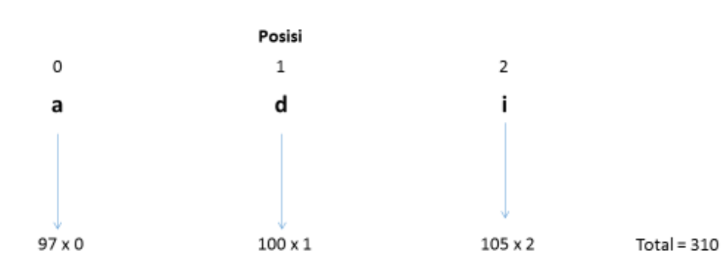

# Penanganan Collusion
Perfect Hash Function meminimalisir terjadinya colluision, akan tetapi terkadang, collusion ini tidak
dapat dihindari, sehingga diperluka penanganan atau yang dikenal dengan collusion resolution.

Penangan collusion ini dapat dilakukan dengan cara mencari kembali di dalam hash table slot
yang kosong untuk data yang menyebabkan terjadinya collusion. Penanganan ini dikenal dengan
konsep open addressing, yaitu pencarian slot kosong yang siap ditempati oleh data baru.

Contoh penanganan collusion sederhana berdasarkan konsep open adressing ini adalah Linear
Probing, yaitu mencari slot kosong dengan cara mengunjungi slot-slot ini satu persatu, dimulai
dari slot tempat terjadinya collusion.

#### Code
Berikut code untuk pembuatan fungsi Linear Probing.

Misalkan terdapat data a=[54, 26, 93, 17, 77, 31], dan hash function yang digunakan adalah
remainder function, maka tambahkan fungsi linear probing, agar dapat memasukkan data baru
yaitu 44, 55, dan 20, sehingga a= [54, 26, 93, 17, 77, 31, 44, 55, 20]

In [9]:
def linearProbing(ind,hashTable,data):
    count=ind
    found=False

    while (count!=ind-1) and not(found):
    
        if hashTable[count]=='none':
            found=True
            hashTable[count]=data

        else:
            count=count+1
            if count==len(hashTable)-1:
                count=0
        return(hashTable)

def putData3(a,hashTable,functionName):
    
    for i in range(len(a)):
    
        if functionName=='reminder':
            ind=remainderFunction(a[i],len(hashTable))

        elif functionName=='midSq':
            ind=midSqFunction(a[i],len(hashTable))

        if hashTable[ind]=='none':
            hashTable[ind]=a[i]
        else:
            hashTable=linearProbing(ind,hashTable,a[i])

    return(hashTable)

In [10]:
a=[54, 26, 93, 17, 77, 31]
hashTable=createHashTable(11)
print(hashTable)
hashTable=putData3(a,hashTable,'reminder')
print(hashTable)

['none', 'none', 'none', 'none', 'none', 'none', 'none', 'none', 'none', 'none', 'none']
[77, 'none', 'none', 'none', 26, 93, 17, 'none', 'none', 31, 54]


In [11]:
a=[54, 26, 93, 17, 77, 31,44,55,20]
hashTable=createHashTable(11)
print(hashTable)
hashTable=putData3(a,hashTable,'reminder')
print(hashTable)

['none', 'none', 'none', 'none', 'none', 'none', 'none', 'none', 'none', 'none', 'none']
[77, 'none', 'none', 'none', 26, 93, 17, 'none', 'none', 31, 54]


Jika pada Linear Probing, penempatan data dilakukan dengan cara mencari satu persatu slot
kosong dari posisi terjadinya collusion, maka quadratic probing, yaitu data collusion diletakkan
dengan cara menambahkan posisi collusion dengan nilai sebagai berikut : 1, 3, 5, 7, 9, ... Contoh
quadratic probing dapat dilihat pada Gambar berikut :

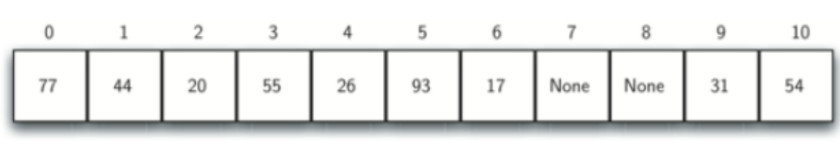

Metode lain untuk penanganan collusion ini adalah Chaining, dengan chaining ini, satu slot dapat
ditempati oleh beberapa data sekaligus. Untuk proses pencarian dilakukan pada slot tersebut.
Contoh chaining ini dapat dilihat pada Gambar berikut:

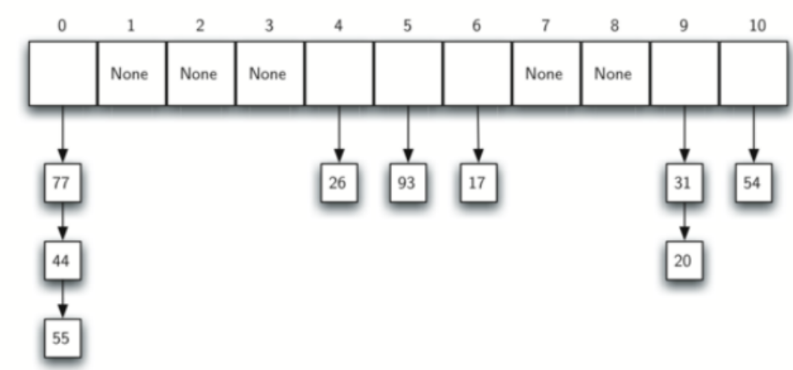